<a href="https://colab.research.google.com/github/mohantyk/txt2img/blob/main/Chap3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import sys
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets.utils import download_url, extract_archive
from torch import nn, optim
import matplotlib.pyplot as plt
import numpy as np
import math

In [45]:
root = r'.'
dataset_dir = os.path.join(root, 'cifar-10-batches-py')

# Faster mirror for the same cifar-10-python.tar.gz file
url = 'https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz'
archive = 'cifar-10-python.tar.gz'
md5 = 'c58f30108f718f92721af3b95e74349a'

if not os.path.isdir(dataset_dir):
    download_url(url, root, archive, md5)
    extract_archive(os.path.join(root, archive), root, remove_finished=True)

trainset = torchvision.datasets.CIFAR10(root=root, train=True, download=False)
testset = torchvision.datasets.CIFAR10(root=root, train=False, download=False)

In [46]:
names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

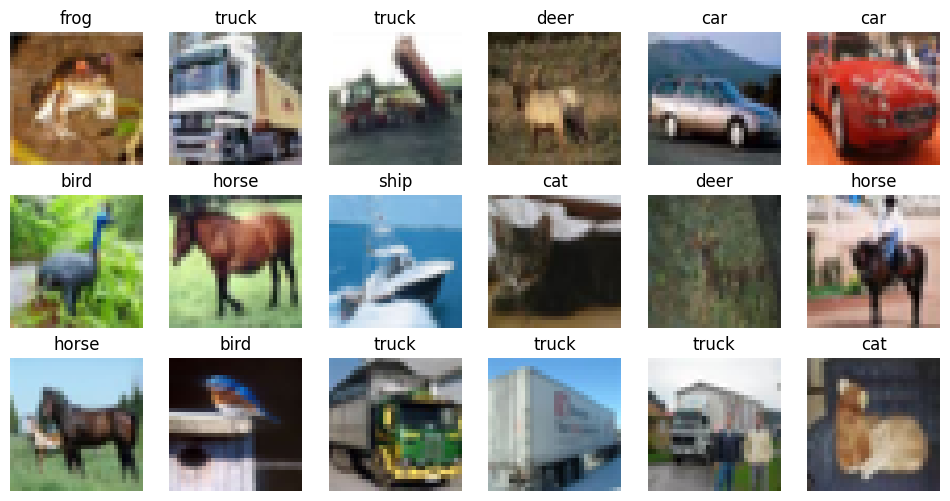

In [47]:
plt.figure(figsize=(12,6),dpi=100)
for i in range(3):
    for j in range(6):
        plt.subplot(3, 6, 6*i+j+1)
        plt.imshow(trainset[6*i+j][0])
        plt.axis('off')
        plt.title(names[trainset[6*i+j][1]], fontsize=12)
plt.subplots_adjust(hspace=0.20)
plt.show()

In [5]:

trainset.transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Resize((32, 32)),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0), ratio=(0.75, 1.3333333333), interpolation=2, antialias=True),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
     ]
)

In [33]:

BATCH_SIZE = 2048
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)


In [34]:
testset.transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((32, 32),antialias=True),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
!git clone https://github.com/markhliu/txt2img
import sys
sys.path.append("/content/txt2img")

Cloning into 'txt2img'...
remote: Enumerating objects: 436, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 436 (delta 81), reused 52 (delta 52), pack-reused 351 (from 1)
Receiving objects: 100% (436/436), 88.66 MiB | 23.98 MiB/s, done.
Resolving deltas: 100% (213/213), done.


In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [10]:
class Config:
  patch_size = 4
  hidden_size = 48
  num_channels = 3
  image_size = 32
  num_attention_heads=4
  intermediate_size = 4 * 48
  num_hidden_layers = 4
  num_classes = 10


config = Config()

In [11]:

class PatchEmbeddings(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.projection = nn.Conv2d(config.num_channels, config.hidden_size,
                                kernel_size=config.patch_size,
                                stride=config.patch_size)

  def forward(self, x):
    x = self.projection(x)
    x = x.flatten(2).transpose(1, 2)
    return x

In [12]:
patchembed = PatchEmbeddings(config)
img = torch.randn((2, 3, 32, 32))
out = patchembed(img)
print(out.shape)

torch.Size([2, 64, 48])


In [13]:
class Embeddings(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.config = config
    self.patch_embeddings = PatchEmbeddings(config)
    self.cls_token = nn.Parameter(torch.randn(1, 1, config.hidden_size))

    num_patches = (config.image_size // config.patch_size) ** 2
    self.position_embeddings = nn.Parameter(torch.randn(1, num_patches+1, config.hidden_size))

  def forward(self, x):
    x = self.patch_embeddings(x)
    batch_size, _, _ = x.size()
    cls_tokens = self.cls_token.expand(batch_size, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)
    x = x + self.position_embeddings
    return x



In [14]:
embed = Embeddings(config)
img = torch.randn((256, 3, 32, 32))
out = embed(img)
print(out.shape)

torch.Size([256, 65, 48])


In [15]:
class AttentionHead(nn.Module):
  def __init__(self, hidden_size, attention_head_size, bias=True):
    super().__init__()
    self.hidden_size = hidden_size
    self.attention_head_size = attention_head_size
    self.query = nn.Linear(hidden_size, attention_head_size, bias=bias)
    self.key = nn.Linear(hidden_size, attention_head_size, bias=bias)
    self.value = nn.Linear(hidden_size, attention_head_size, bias=bias)

  def forward(self, x):
    query = self.query(x)
    key = self.key(x)
    value = self.value(x)
    attention_scores = torch.matmul(query, key.transpose(-1, -2))
    attention_scores = attention_scores / math.sqrt(self.attention_head_size)
    attention_probs = nn.functional.softmax(attention_scores, dim=-1)
    attention_output = torch.matmul(attention_probs, value)
    return (attention_output, attention_probs)

In [16]:
class MultiHeadAttention(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.hidden_size = config.hidden_size
    self.num_attention_heads = config.num_attention_heads
    self.attention_head_size = self.hidden_size // self.num_attention_heads
    self.all_head_size = self.num_attention_heads * self.attention_head_size
    self.heads = nn.ModuleList([])
    for _ in range(self.num_attention_heads):
      head = AttentionHead(self.hidden_size, self.attention_head_size)
      self.heads.append(head)
    self.output_projection = nn.Linear(self.all_head_size, self.hidden_size)


  def forward(self, x, output_attentions=False):
    attention_outputs = [head(x) for head in self.heads]
    attention_output = torch.cat([attention_output for attention_output, _ in attention_outputs], dim=-1)
    attention_output = self.output_projection(attention_output)

    if not output_attentions:
      return (attention_output, None)
    else:
      attention_probs = torch.stack([attention_probs for _, attention_probs in attention_outputs], dim=1)
      return (attention_output, attention_probs)

In [17]:
class GELU(nn.Module):
    def forward(self, input):
        return 0.5 * input * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) *\
                           (input + 0.044715 * torch.pow(input, 3.0))))


In [18]:
class MLP(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.dense_1 = nn.Linear(config.hidden_size, config.intermediate_size)
    self.activation = GELU()
    self.dense_2 = nn.Linear(config.intermediate_size, config.hidden_size)

  def forward(self, x):
    x = self.dense_1(x)
    x = self.activation(x)
    x = self.dense_2(x)
    return x

In [19]:
class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.attention = MultiHeadAttention(config)
    self.layernorm_1 = nn.LayerNorm(config.hidden_size)
    self.mlp = MLP(config)
    self.layernorm_2 = nn.LayerNorm(config.hidden_size)

  def forward(self, x, output_attentions=False):
    attention_output, attention_probs = self.attention(self.layernorm_1(x),
                                                       output_attentions=output_attentions)
    x = x + attention_output
    mlp_output = self.mlp(self.layernorm_2(x))
    x = x + mlp_output
    if not output_attentions:
      return (x, None)
    else:
      return (x, attention_probs)


In [20]:
class Encoder(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.blocks = nn.ModuleList([])
    for _ in range(config.num_hidden_layers):
      block = Block(config)
      self.blocks.append(block)

  def forward(self, x, output_attentions=False):
    all_attentions = []
    for block in self.blocks:
      x, attention_probs = block(x, output_attentions=output_attentions)
      if output_attentions:
        all_attentions.append(attention_probs)
    if not output_attentions:
      return (x, None)
    else:
      return (x, all_attentions)

In [21]:
class ViTForClassification(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.config = config
    self.image_size = config.image_size
    self.hidden_size = config.hidden_size
    self.num_classes = config.num_classes
    self.embedding = Embeddings(config)
    self.encoder = Encoder(config)
    self.classifier = nn.Linear(self.hidden_size, self.num_classes)
    self.apply(self._init_weights)

  def _init_weights(self, module):
    if isinstance(module, (nn.Linear, nn.Conv2d)):
      torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
      if module.bias is not None:
        torch.nn.init.zeros_(module.bias)
    elif isinstance(module, nn.LayerNorm):
      module.bias.data.zero_()
      module.weight.data.fill_(1.0)
    elif isinstance(module, Embeddings):
      module.position_embeddings.data = nn.init.trunc_normal_(
                module.position_embeddings.data.to(torch.float32),
                mean=0.0,std=0.02,).to(module.position_embeddings.dtype)
      module.cls_token.data = nn.init.trunc_normal_(
          module.cls_token.data.to(torch.float32),
          mean=0.0,std=0.02,).to(module.cls_token.dtype)

  def forward(self, x, output_attentions=False):
    embedding_output = self.embedding(x)
    encoder_output, all_attentions = self.encoder(embedding_output, output_attentions)
    logits = self.classifier(encoder_output[:, 0, :])
    if not output_attentions:
      return (logits, None)
    else:
      return (logits, all_attentions)

## Training

In [23]:
class EarlyStop:
  def __init__(self, patience=3):
    self.patience = patience
    self.steps = 0
    self.min_loss = float('inf')

  def stop(self, loss):
    if loss < self.min_loss:
      self.min_loss = loss
      self.steps = 0
      to_save = True
    elif loss >= self.min_loss:
      self.steps += 1
      to_save = False

    if self.steps >= self.patience:
      to_stop = True
    else:
      to_stop = False
    return to_save, to_stop



In [24]:
def train_batch(batch):
  batch = [t.to(device) for t in batch]
  images, labels = batch
  with torch.amp.autocast(device):
    loss = loss_fn(model(images)[0], labels)
  optimizer.zero_grad()
  scaler.scale(loss).backward()
  scaler.step(optimizer)
  scaler.update()
  return loss.item() * len(images) / len(trainloader.dataset)

In [25]:
from tqdm import tqdm
import os
os.makedirs('files', exist_ok=True)

In [41]:
model = ViTForClassification(config).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=1e-2)
loss_fn = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler()
stopper = EarlyStop()

In [42]:
for i in range(100):
  print(f'Epoch {i+1}')
  model.train()
  trainL, testL = 0, 0
  for batch in tqdm(trainloader):
    loss = train_batch(batch)
    trainL += loss
  model.eval()
  with torch.no_grad():
    for batch in testloader:
      batch = [t.to(device) for t in batch]
      images, labels = batch
      logits, _ = model(images)
      loss = loss_fn(logits, labels)
      testL += loss.item() * len(images) / len(testloader.dataset)

  print(f'Train and test losses: {trainL:.4f}, {testL:.4f}')
  to_save, to_stop = stopper.stop(testL)
  print(f"epoch {i+1}: testL={testL:.4f}, steps={stopper.steps}, to_stop={to_stop}")
  if to_save:
    torch.save(model.state_dict(), 'files/ViT.pth')
  if to_stop:
    break


Epoch 1


100%|██████████| 25/25 [00:36<00:00,  1.45s/it]


Train and test losses: 2.1057, 1.9813
epoch 1: testL=1.9813, steps=0, to_stop=False
Epoch 2


100%|██████████| 25/25 [00:35<00:00,  1.43s/it]


Train and test losses: 1.9374, 1.8725
epoch 2: testL=1.8725, steps=0, to_stop=False
Epoch 3


...

Train and test losses: 1.1227, 1.1846
epoch 17: testL=1.1846, steps=1, to_stop=False
Epoch 18


100%|██████████| 25/25 [00:35<00:00,  1.42s/it]


Train and test losses: 1.1065, 1.1930
epoch 18: testL=1.1930, steps=2, to_stop=False
Epoch 19


100%|██████████| 25/25 [00:36<00:00,  1.44s/it]


Train and test losses: 1.0907, 1.1596
epoch 19: testL=1.1596, steps=3, to_stop=True


## Classification

In [49]:
import math
import torch.nn.functional as F

In [53]:
model.load_state_dict(torch.load('files/ViT.pth'))
model.eval()
with torch.no_grad():
  batch = next(iter(testloader))
  batch = [t.to(device) for t in batch]
  images, labels = batch
  logits, attention_maps = model(images, output_attentions=True)
  predictions = torch.argmax(logits, dim=1)

print(predictions)
print([names[i] for i in predictions.tolist()])

tensor([3, 8, 8,  ..., 9, 3, 5], device='cuda:0')
['cat', 'ship', 'ship', 'plane', 'frog', 'frog', 'cat', 'frog', 'dog', 'car', 'plane', 'truck', 'dog', 'horse', 'truck', 'deer', 'dog', 'horse', 'ship', 'frog', 'horse', 'plane', 'plane', 'truck', 'deer', 'dog', 'deer', 'bird', 'car', 'frog', 'cat', 'dog', 'deer', 'cat', 'truck', 'car', 'dog', 'truck', 'truck', 'dog', 'deer', 'frog', 'dog', 'cat', 'plane', 'truck', 'dog', 'truck', 'horse', 'frog', 'truck', 'deer', 'frog', 'cat', 'ship', 'ship', 'dog', 'dog', 'dog', 'cat', 'horse', 'dog', 'frog', 'dog', 'bird', 'deer', 'car', 'plane', 'dog', 'horse', 'bird', 'cat', 'ship', 'ship', 'deer', 'bird', 'truck', 'dog', 'cat', 'ship', 'ship', 'car', 'car', 'dog', 'plane', 'horse', 'deer', 'deer', 'ship', 'truck', 'plane', 'dog', 'ship', 'frog', 'deer', 'horse', 'frog', 'plane', 'plane', 'horse', 'bird', 'deer', 'frog', 'cat', 'car', 'ship', 'cat', 'frog', 'dog', 'dog', 'dog', 'plane', 'bird', 'dog', 'car', 'cat', 'plane', 'truck', 'cat', 'dog', 

attention map shape: torch.Size([2048, 16, 65, 65])
attention map shape: torch.Size([2048, 16, 64])
attention map shape: torch.Size([2048, 64])
attention map shape: torch.Size([2048, 8, 8])
attention map shape: torch.Size([2048, 32, 32])


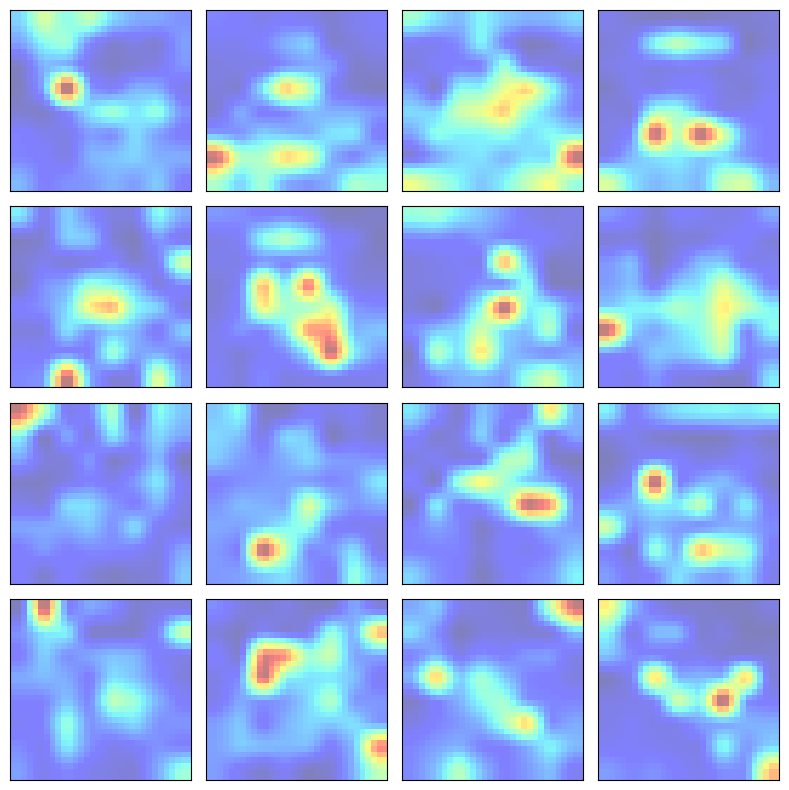

In [54]:
with torch.no_grad():
    attention_maps = torch.cat(attention_maps, dim=1)
    print(f"attention map shape: {attention_maps.shape}")
    attention_maps = attention_maps[:, :, 0, 1:]
    print(f"attention map shape: {attention_maps.shape}")
    attention_maps = attention_maps.mean(dim=1)
    print(f"attention map shape: {attention_maps.shape}")
    num_patches = attention_maps.size(-1)
    size = int(math.sqrt(num_patches))
    attention_maps = attention_maps.view(-1, size, size)
    print(f"attention map shape: {attention_maps.shape}")
    attention_maps = attention_maps.unsqueeze(1)
    attention_maps = F.interpolate(attention_maps, size=(32, 32),
                       mode='bilinear', align_corners=False)
    attention_maps = attention_maps.squeeze(1)    #D
    print(f"attention map shape: {attention_maps.shape}")

fig = plt.figure(figsize=(8, 8),dpi=100)
for i in range(16):
    ax = fig.add_subplot(4,4, i+1, xticks=[], yticks=[])
    ax.imshow(attention_maps[i].cpu(), alpha=0.5, cmap='jet')
plt.tight_layout()
plt.show()

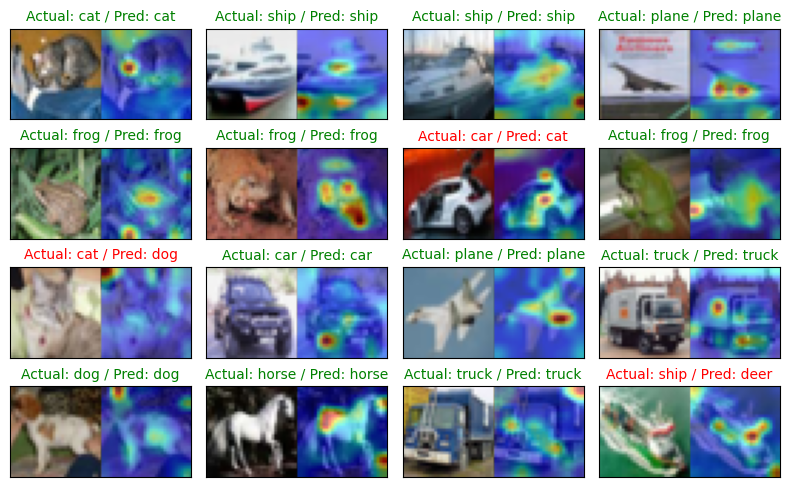

In [55]:
fig = plt.figure(figsize=(8, 5),dpi=100)
mask = np.concatenate([np.ones((32, 32)), np.zeros((32, 32))],
                      axis=1)
for i in range(16):
    ax = fig.add_subplot(4,4, i+1, xticks=[], yticks=[])
    img = np.concatenate((images[i].cpu(), images[i].cpu()),
                         axis=-1)
    ax.imshow(img.transpose(1,2,0)/2+0.5)
    extended_attention_map = np.concatenate((np.zeros((32, 32)),
                                     attention_maps[i].cpu()),
                                            axis=1)
    extended_attention_map = np.ma.masked_where(mask==1,
                                    extended_attention_map)
    ax.imshow(extended_attention_map, alpha=0.5, cmap='jet')
    gt = names[labels[i]]
    pred = names[predictions[i]]
    ax.set_title(f"Actual: {gt} / Pred: {pred}",
                 color=("green" if gt==pred else "red"),
                fontsize=10)
plt.tight_layout()
plt.show()

In [56]:
model.eval()
acc = 0
with torch.no_grad():
    for batch in testloader:  #1
        batch = [t.to(device) for t in batch]
        images, labels = batch
        logits, _ = model(images)
        predictions = torch.argmax(logits, dim=1)  #2
        acc += torch.sum(predictions ==\
             labels).item()/ len(testloader.dataset)
print(f'the prediction accuracy is {acc:.4f}')  #3

the prediction accuracy is 0.5788
